<a href="https://colab.research.google.com/github/ridhima812/DLLAB/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 5: LSTM Text Classification with Seq2Seq

### 1. Problem Statement
Build an LSTM model to classify text into categories (e.g., positive vs negative sentiment).

### 2. Dataset (Recommended)
Use:
* IMDB Dataset (built into TensorFlow)
* Binary classification: Positive / Negative reviews

### 3. Step-by-Step Implementation

#### 🔹 Step 1: Import Libraries

In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

#### 🔹 Step 2: Load Dataset

In [ ]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 🔹 Step 3: Preprocessing (Padding)
👉 This ensures all sequences have equal length.

In [ ]:
max_len = 200  # max words per review

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

#### 🔹 Step 4: Build LSTM Model

In [ ]:
model = Sequential()

# Convert words into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### 🔹 Step 5: Compile Model

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#### 🔹 Step 6: Train Model

#### 🔹 Step 6: Train Model (Continued)

Re-running the training as it was interrupted.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.9044 - loss: 0.2423 - val_accuracy: 0.8706 - val_loss: 0.3207
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.9333 - loss: 0.1767 - val_accuracy: 0.8632 - val_loss: 0.3490
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.9546 - loss: 0.1295 - val_accuracy: 0.8666 - val_loss: 0.3961
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 264ms/step - accuracy: 0.9424 - loss: 0.1587 - val_accuracy: 0.8460 - val_loss: 0.4301
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.9575 - loss: 0.1206 - val_accuracy: 0.8430 - val_loss: 0.4305


#### 🔹 Step 7: Evaluate Model (Continued)

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.8464 - loss: 0.4364
Test Accuracy: 0.8464400172233582


### 5. Plot Graphs (Continued)

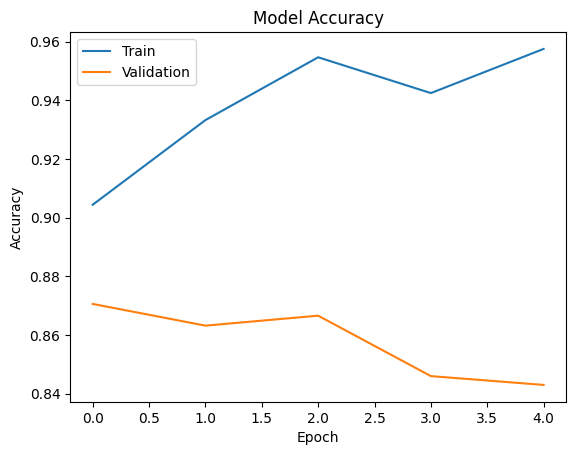

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

#### 🔹 Step 7: Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

### 4. Expected Output
* Accuracy: ~85% – 88%
* Training time: Moderate
* Better than simple RNN

### 5. Plot Graphs

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

### 6. Explanation
* Embedding Layer: Converts words into vectors
* LSTM Layer: Captures sequence dependencies
* Sigmoid Output: Binary classification

### 7. Why LSTM Works Better?
* Remembers long-term dependencies
* Avoids vanishing gradient problem
* Captures context in sentences

### 8. Final Conclusion
The LSTM model effectively captures sequential dependencies in text data, leading to improved classification performance compared to traditional neural networks. It is well-suited for natural language processing tasks such as sentiment analysis.

### Improvements (For Extra Marks)
Try adding:

`model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))`

OR stack layers:

`model.add(LSTM(64, return_sequences=True))`
`model.add(LSTM(32))`